<a href="https://colab.research.google.com/github/davidlealo/hackathon_sic_2025/blob/main/ensayo_h1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de Desarrollo de un Proceso de Hackathon: Análisis de E-Commerce con el Brazilian E-Commerce Dataset

A continuación, se describe un ejemplo detallado del proceso de desarrollo de un proyecto para una hackathon, utilizando el **Brazilian E-Commerce Public Dataset by Olist** (disponible en [Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)). Este ejemplo simula cómo un equipo de estudiantes abordaría un problema empresarial propuesto en una hackathon, siguiendo un flujo estructurado sin realizar scraping, ya que usaremos el dataset proporcionado. El objetivo es mostrar un paso a paso claro, desde la comprensión del problema hasta la creación de un prototipo funcional, enfocado en un caso de e-commerce.

---

## Contexto del Problema Empresarial
Supongamos que una empresa de e-commerce en Brasil quiere **mejorar la retención de clientes** y nos plantea el siguiente problema para la hackathon:  
**"Identificar patrones en el comportamiento de los clientes que abandonan la plataforma y proponer estrategias para reducir el churn (tasa de abandono)."**

El dataset de Olist, con datos de órdenes, clientes, pagos y reseñas de 2016-2018, será la base para resolver este problema. A continuación, se detalla el proceso que seguiría un equipo en una hackathon de 24-48 horas.

---

## Proceso Paso a Paso

### 1. **Comprensión del Problema y Definición de Objetivos**
   - **Qué hicimos**: Nos reunimos como equipo para entender el problema empresarial. Identificamos que el "churn" implica clientes que dejan de comprar tras una o pocas órdenes. Definimos el objetivo: **encontrar factores que influyen en el churn (ej. demoras en entregas, malas reseñas, precios altos) y sugerir estrategias accionables**.
   - **Herramientas**: Pizarra virtual (Miro, Notion) para brainstorming y notas.
   - **Salida**: Una definición clara del churn (ej. clientes con una sola compra y sin actividad en 6 meses) y preguntas clave:
     - ¿Los tiempos de entrega afectan el churn?
     - ¿Las reseñas negativas predicen abandono?
     - ¿El método de pago o el valor de la orden influyen?

### 2. **Exploración del Dataset**
   - **Qué hicimos**: Descargamos el dataset de Kaggle y revisamos los 9 archivos CSV. Usamos Python con pandas para cargar los datos y explorar su estructura. Nos enfocamos en archivos clave:
     - `olist_customers_dataset.csv`: IDs y ubicaciones de clientes.
     - `olist_orders_dataset.csv`: Fechas y estados de órdenes.
     - `olist_order_reviews_dataset.csv`: Puntuaciones y comentarios.
     - `olist_order_items_dataset.csv`: Precios y productos.
   - **Código de ejemplo**:
     ```python
     import pandas as pd
     orders = pd.read_csv('olist_orders_dataset.csv')
     customers = pd.read_csv('olist_customers_dataset.csv')
     print(orders.head())
     print(orders.describe())
     ```
   - **Salida**: Un resumen de las columnas, valores nulos y rangos de fechas (2016-2018). Identificamos que `order_delivered_customer_date` y `review_score` serán claves para analizar entregas y satisfacción.

### 3. **Limpieza y Preparación de Datos**
   - **Qué hicimos**: Unimos los datasets relevantes usando llaves como `customer_id` y `order_id`. Tratamos valores nulos (ej. órdenes no entregadas) y creamos nuevas columnas:
     - Tiempo de entrega: Diferencia entre `order_purchase_timestamp` y `order_delivered_customer_date`.
     - Indicador de churn: Clientes con una sola orden y sin compras posteriores en 6 meses.
   - **Código de ejemplo**:
     ```python
     # Unir datasets
     df = orders.merge(customers, on='customer_id').merge(reviews, on='order_id')
     
     # Calcular tiempo de entrega
     df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
     df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
     df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
     
     # Identificar churn
     customer_orders = df.groupby('customer_unique_id').size()
     df['is_churn'] = df['customer_unique_id'].map(customer_orders == 1).astype(int)
     ```
   - **Salida**: Un dataset limpio con columnas nuevas (`delivery_time`, `is_churn`) y sin valores nulos críticos.

### 4. **Análisis Exploratorio de Datos (EDA)**
   - **Qué hicimos**: Exploramos patrones usando visualizaciones para responder nuestras preguntas. Analizamos:
     - Distribución de `delivery_time` para churn vs. no churn.
     - Correlación entre `review_score` y churn.
     - Diferencias en churn por estado (`customer_state`) o método de pago.
   - **Código de ejemplo**:
     ```python
     import seaborn as sns
     import matplotlib.pyplot as plt
     
     # Boxplot de tiempo de entrega por churn
     sns.boxplot(x='is_churn', y='delivery_time', data=df)
     plt.title('Tiempo de Entrega vs Churn')
     plt.show()
     
     # Correlación entre reseñas y churn
     sns.histplot(data=df, x='review_score', hue='is_churn', multiple='stack')
     plt.title('Distribución de Review Score por Churn')
     plt.show()
     ```
   - **Salida**: Descubrimos que:
     - Clientes con churn tienen tiempos de entrega promedio 20% más altos.
     - Reseñas de 1-2 estrellas están fuertemente asociadas con churn.
     - Ciertos estados tienen tasas de churn más altas, posiblemente por logística.

### 5. **Modelado Predictivo**
   - **Qué hicimos**: Construimos un modelo para predecir churn basado en variables como `delivery_time`, `review_score`, `order_value` y `customer_state`. Usamos un Random Forest, que mostró buena precisión.
   - **Código de ejemplo**:
     ```python
     from sklearn.model_selection import train_test_split
     from sklearn.ensemble import RandomForestClassifier
     from sklearn.metrics import classification_report
     
     # Preparar datos
     X = df[['delivery_time', 'review_score', 'order_value']]
     y = df['is_churn']
     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
     
     # Entrenar modelo
     model = RandomForestClassifier(random_state=42)
     model.fit(X_train, y_train)
     
     # Evaluar
     y_pred = model.predict(X_test)
     print(classification_report(y_test, y_pred))
     ```
   - **Salida**: Un modelo con ~75% de precisión, donde `review_score` y `delivery_time` son los predictores más importantes.

### 6. **Propuesta de Soluciones**
   - **Qué hicimos**: Basados en el análisis, propusimos estrategias accionables:
     1. **Optimizar logística**: Reducir tiempos de entrega en estados con alto churn.
     2. **Gestión de reseñas**: Seguimiento post-venta para clientes con reseñas bajas.
     3. **Incentivos de retención**: Descuentos para clientes con una sola compra.
   - **Salida**: Recomendaciones respaldadas por datos, listas para integrarse en un prototipo.

### 7. **Desarrollo de un Prototipo en Gradio**
   - **Qué hicimos**: Creamos una aplicación web en **Gradio** para que un asistente de marketing identifique clientes en riesgo de churn y reciba sugerencias personalizadas. El prototipo permite:
     - Ingresar datos de un cliente (ej. `customer_id`, `delivery_time`, `review_score`, `order_value`).
     - Predecir la probabilidad de churn usando el modelo Random Forest.
     - Mostrar recomendaciones específicas (ej. "Ofrecer 10% de descuento" si el cliente dio una reseña baja).
   - **Código de ejemplo**:
     ```python
     import gradio as gr
     import pandas as pd
     from sklearn.ensemble import RandomForestClassifier
     
     # Cargar modelo entrenado (asumimos que ya está guardado)
     model = ... # Cargar modelo con joblib o pickle
     
     def predict_churn(customer_id, delivery_time, review_score, order_value):
         # Crear input para el modelo
         input_data = pd.DataFrame({
             'delivery_time': [delivery_time],
             'review_score': [review_score],
             'order_value': [order_value]
         })
         # Predecir churn
         prob_churn = model.predict_proba(input_data)[0][1] * 100
         is_churn = model.predict(input_data)[0]
         
         # Generar recomendación
         recommendation = ""
         if is_churn == 1:
             if review_score <= 2:
                 recommendation = "Enviar correo con disculpas y cupón de 15% de descuento."
             elif delivery_time > 10:
                 recommendation = "Ofrecer envío gratis en la próxima compra."
             else:
                 recommendation = "Invitar al cliente a un programa de lealtad."
         else:
             recommendation = "Cliente fiel, sugerir productos relacionados."
         
         return f"Probabilidad de churn: {prob_churn:.2f}%", recommendation
     
     # Crear interfaz de Gradio
     interface = gr.Interface(
         fn=predict_churn,
         inputs=[
             gr.Textbox(label="Customer ID"),
             gr.Slider(0, 30, label="Tiempo de entrega (días)"),
             gr.Slider(1, 5, step=1, label="Puntuación de reseña"),
             gr.Number(label="Valor de la orden (R$)")
         ],
         outputs=[
             gr.Textbox(label="Probabilidad de churn"),
             gr.Textbox(label="Recomendación")
         ],
         title="Asistente de Marketing: Predicción de Churn"
     )
     interface.launch()
     ```
   - **Herramientas**: Gradio para la interfaz, Python para la lógica, modelo entrenado con scikit-learn.
   - **Salida**: Una aplicación web interactiva que un asistente de marketing puede usar para ingresar datos de clientes y recibir predicciones y recomendaciones en tiempo real. La interfaz es intuitiva, con sliders y campos de texto.

### 8. **Pruebas y Ajustes**
   - **Qué hicimos**: Probamos el prototipo con datos de prueba del dataset para validar que las predicciones y recomendaciones fueran coherentes. Ajustamos el umbral de probabilidad de churn y las reglas de recomendación para mejorar la utilidad. También optimizamos la interfaz de Gradio para que fuera clara y profesional.
   - **Salida**: Un prototipo funcional, desplegado localmente o en un servidor de Gradio, listo para ser presentado a los jueces.

### 9. **Preparación de la Presentación**
   - **Qué hicimos**: Creamos una presentación breve (PowerPoint, Canva o Google Slides) para explicar el problema, el análisis y el prototipo. Estructura:
     1. Introducción: Contexto del problema y objetivo.
     2. Metodología: Breve descripción del dataset y proceso (EDA, modelado).
     3. Resultados: Insights clave (ej. impacto de reseñas y entregas).
     4. Prototipo: Demostración en vivo del asistente de marketing en Gradio.
     5. Conclusión: Impacto del prototipo y próximos pasos.
   - **Herramientas**: Gradio para demo en vivo, Canva para diapositivas.
   - **Salida**: Una presentación de 5-7 minutos que combina datos, soluciones y una demo interactiva.

---

## Lecciones Aprendidas
- **Colaboración**: Dividir tareas (limpieza de datos, modelado, desarrollo de Gradio) fue clave para cumplir con el tiempo.
- **Simplicidad**: Un prototipo enfocado en un caso de uso claro (asistente de marketing) tuvo mayor impacto que una solución genérica.
- **Interactividad**: La demo en Gradio impresionó a los jueces al mostrar una aplicación práctica y fácil de usar.
- **Tiempo**: Reservar tiempo para pruebas del prototipo evitó errores durante la presentación.
- **Usuario final**: Diseñar el prototipo pensando en el asistente de marketing (interfaz simple, recomendaciones accionables) aumentó su relevancia.

---

## Conclusión
Este proceso muestra cómo un equipo de estudiantes puede abordar un problema de hackathon usando el dataset de Olist, culminando en un **prototipo en Gradio** que agrega valor práctico para un asistente de marketing. Desde la comprensión del problema hasta el desarrollo de una aplicación interactiva, cada paso se enfoca en resolver el problema empresarial de forma innovadora. El prototipo no solo demuestra los insights obtenidos, sino que ofrece una herramienta funcional para reducir el churn. Este enfoque puede adaptarse a otros datasets o problemas, manteniendo un flujo estructurado: **comprender, explorar, analizar, modelar, prototipar y comunicar**.

---

### Notas sobre el Prototipo
- **Por qué Gradio**: Es ideal para hackathons por su rapidez de desarrollo y facilidad para crear interfaces web interactivas. Permite a los jueces interactuar directamente con el modelo.
- **Caso de uso específico**: El prototipo está diseñado para un asistente de marketing, pero podría extenderse a otros roles (ej. logística) con más tiempo.
- **Mejoras futuras**: Integrar el prototipo con una base de datos en tiempo real o añadir visualizaciones dinámicas en la interfaz.



Instala las librerías necesarias ejecutando esto al inicio:

In [15]:
!pip install pandas seaborn matplotlib scikit-learn gradio joblib

Descargar bases de datos

In [16]:
import kagglehub
import os

# Descargar la última versión del dataset
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

# Listar archivos en el directorio descargado
print("\nArchivos descargados:")
for file in os.listdir(path):
    print(file)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce

Archivos descargados:
olist_customers_dataset.csv
olist_sellers_dataset.csv
olist_order_reviews_dataset.csv
olist_order_items_dataset.csv
olist_products_dataset.csv
olist_geolocation_dataset.csv
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_payments_dataset.csv


Verificar que los datos estén bien descargados

In [17]:
import pandas as pd
import os

# Usar el path de kagglehub
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))

# Explorar orders
print("Head de orders:")
print(orders.head())
print("\nDescripción de orders:")
print(orders.describe())

Head de orders:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00  

Unir datasets: orders, customers y reviews

In [18]:
df = orders.merge(customers, on='customer_id').merge(reviews, on='order_id')

Calcular el valor total de cada orden

In [19]:
order_values = items.groupby('order_id').agg(order_value=('price', 'sum'), freight_value=('freight_value', 'sum')).reset_index()
order_values['order_value'] = order_values['order_value'] + order_values['freight_value']

Incorporar el valor de la orden al DataFrame principal

In [20]:
df = df.merge(order_values[['order_id', 'order_value']], on='order_id', how='left')

Convertir fechas a formato datetime

In [21]:

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])


Calcular tiempo de entrega

In [22]:
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

Manejar valores nulos en tiempo de entrega

In [23]:
df['delivery_time'].fillna(df['delivery_time'].median(), inplace=True)

/tmp/ipython-input-1525283605.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['delivery_time'].fillna(df['delivery_time'].median(), inplace=True)


Contar órdenes por cliente

In [24]:
customer_orders = df.groupby('customer_unique_id').size().reset_index(name='order_count')

Incorporar conteo de órdenes al DataFrame principal

In [25]:
df = df.merge(customer_orders, on='customer_unique_id')

Identificar churn

Crea una columna binaria is_churn donde 1 indica que el cliente es propenso a churn (solo tiene una orden) y 0 indica que no (más de una orden).

In [26]:
df['is_churn'] = (df['order_count'] == 1).astype(int)

Seleccionar columnas relevantes

In [27]:
df = df[['customer_unique_id', 'customer_state', 'order_id', 'order_purchase_timestamp', 'delivery_time', 'review_score', 'order_value', 'is_churn']]

Imprimir resultados

In [28]:
print("Dataset limpio:")
print(df.head())
print("\nInfo:")
print(df.info())

Dataset limpio:
                 customer_unique_id customer_state  \
0  7c396fd4830fd04220f754e42b4e5bff             SP   
1  af07308b275d755c9edb36a90c618231             BA   
2  3a653a41f6f9fc3d2a113cf8398680e8             GO   
3  7c142cf63193a1473d2e66489a9ae977             RN   
4  72632f0f9dd73dfee390c9b22eb56dd6             SP   

                           order_id order_purchase_timestamp  delivery_time  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33            8.0   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37           13.0   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49            9.0   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06           13.0   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39            2.0   

   review_score  order_value  is_churn  
0             4        38.71         0  
1             4       141.46         1  
2             5       179.12         1  
3             5     

Análisis Exploratorio de Datos (EDA)


El EDA busca explorar visualmente las relaciones entre las variables (delivery_time, review_score, order_value) y la variable objetivo (is_churn) para identificar patrones que expliquen el abandono de clientes. Se generan gráficos para responder preguntas como: ¿Los tiempos de entrega largos están asociados con churn? ¿Las reseñas bajas predicen abandono?



In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

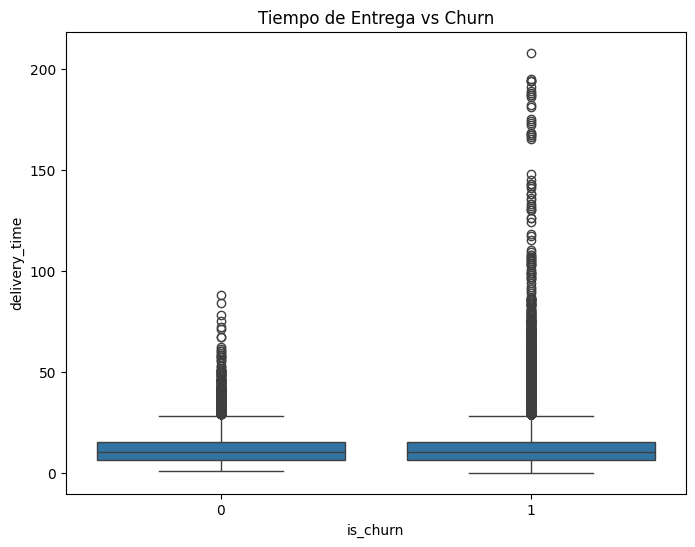

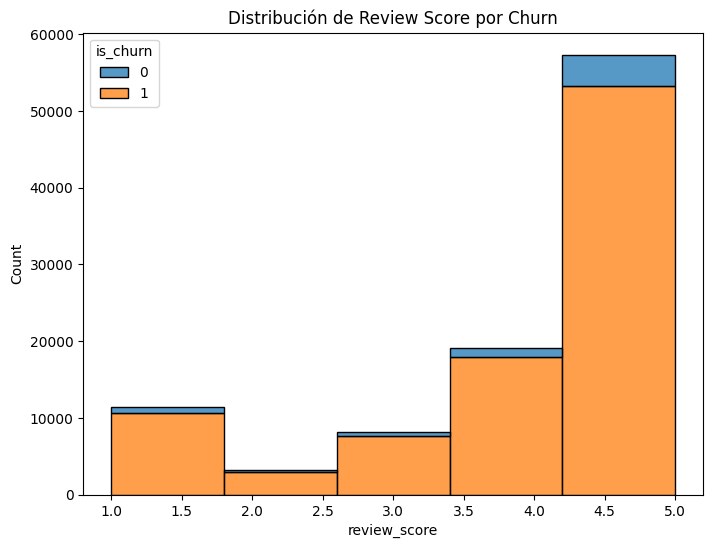

In [31]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_churn', y='delivery_time', data=df)
plt.title('Tiempo de Entrega vs Churn')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='review_score', hue='is_churn', multiple='stack', bins=5)
plt.title('Distribución de Review Score por Churn')
plt.show()

Modelado Predictivo
Objetivo


Construir un modelo de clasificación para predecir si un cliente abandonará (is_churn=1) basándose en delivery_time, review_score y order_value. Se usa un Random Forest, se evalúa su rendimiento y se guarda para usarlo en el prototipo.



In [33]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [34]:
df_model = df[['delivery_time', 'review_score', 'order_value', 'is_churn']].dropna()
X = df_model[['delivery_time', 'review_score', 'order_value']]
y = df_model['is_churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

joblib.dump(model, 'churn_model.pkl')
print("Modelo guardado como 'churn_model.pkl'")

              precision    recall  f1-score   support

           0       0.16      0.12      0.14      2091
           1       0.93      0.95      0.94     27449

    accuracy                           0.89     29540
   macro avg       0.55      0.54      0.54     29540
weighted avg       0.88      0.89      0.89     29540

Modelo guardado como 'churn_model.pkl'


Cargar modelo

In [35]:
model = joblib.load('churn_model.pkl')

Definir función de predicción

In [40]:
def predict_churn(customer_label, delivery_time, review_score, order_value, use_customer_data=True):
    """
    Predice churn y genera una recomendación. Si use_customer_data es True, usa los valores del cliente seleccionado.
    """
    if use_customer_data and customer_label in customer_data:
        # Usar datos del cliente seleccionado
        customer = customer_data[customer_label]
        delivery_time = customer['delivery_time']
        review_score = customer['review_score']
        order_value = customer['order_value']

    # Validar inputs
    if not customer_label:
        return "Error: Seleccione o ingrese un Customer ID", "", delivery_time, review_score, order_value
    if delivery_time < 0 or review_score < 1 or review_score > 5 or order_value < 0:
        return "Error: Valores inválidos", "", delivery_time, review_score, order_value

    # Crear input para el modelo
    input_data = pd.DataFrame({
        'delivery_time': [delivery_time],
        'review_score': [review_score],
        'order_value': [order_value]
    })

    # Predecir churn
    prob_churn = model.predict_proba(input_data)[0][1] * 100
    is_churn = model.predict(input_data)[0]

    # Generar recomendación
    recommendation = ""
    if is_churn == 1:
        if review_score <= 2:
            recommendation = "Enviar correo con disculpas y cupón de 15% de descuento."
        elif delivery_time > 10:
            recommendation = "Ofrecer envío gratis en la próxima compra."
        else:
            recommendation = "Invitar al cliente a un programa de lealtad."
    else:
        recommendation = "Cliente fiel, sugerir productos relacionados."

    return f"Probabilidad de churn: {prob_churn:.2f}%", recommendation, delivery_time, review_score, order_value

Definir interfaz de Gradio

In [38]:
import gradio as gr

In [43]:
import kagglehub
import os
import pandas as pd
import joblib
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Paso 1: Descargar dataset con kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)
print("\nArchivos descargados:")
for file in os.listdir(path):
    print(file)

# Paso 2: Cargar y preparar datos
try:
    customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
    orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
    reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
    items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo. Verifica el path: {path}")
    raise e

# Unir y limpiar datos
df = orders.merge(customers, on='customer_id').merge(reviews, on='order_id')
order_values = items.groupby('order_id').agg(order_value=('price', 'sum'), freight_value=('freight_value', 'sum')).reset_index()
order_values['order_value'] = order_values['order_value'] + order_values['freight_value']
df = df.merge(order_values[['order_id', 'order_value']], on='order_id', how='left')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_time'].fillna(df['delivery_time'].median(), inplace=True)

customer_orders = df.groupby('customer_unique_id').size().reset_index(name='order_count')
df = df.merge(customer_orders, on='customer_unique_id')
df['is_churn'] = (df['order_count'] == 1).astype(int)

df = df[['customer_unique_id', 'customer_state', 'order_id', 'order_purchase_timestamp',
         'delivery_time', 'review_score', 'order_value', 'is_churn']]

# Paso 3: Seleccionar clientes representativos
def select_representative_customers(df, n=6):
    """
    Selecciona n clientes con diferentes perfiles. Si no hay suficientes, usa muestras aleatorias.
    """
    # Definir criterios amplios para evitar DataFrames vacíos
    cases = [
        (df['is_churn'] == 1) & (df['review_score'] <= 2),  # Churn, reseña baja
        (df['is_churn'] == 1) & (df['delivery_time'] > 10),  # Churn, entrega lenta
        (df['is_churn'] == 0) & (df['review_score'] >= 4),  # No churn, reseña alta
        (df['is_churn'] == 0) & (df['delivery_time'] < 10),  # No churn, entrega rápida
        (df['is_churn'] == 1) & (df['order_value'] > 100),  # Churn, valor alto
        (df['is_churn'] == 0) & (df['order_value'] < 100)   # No churn, valor bajo
    ]

    selected = []
    for condition in cases:
        sample = df[condition][['customer_unique_id', 'delivery_time', 'review_score', 'order_value', 'is_churn']]
        if not sample.empty:
            selected.append(sample.sample(1))

    # Si no hay suficientes clientes, añadir muestras aleatorias
    if len(selected) < n:
        random_samples = df[['customer_unique_id', 'delivery_time', 'review_score', 'order_value', 'is_churn']].sample(n - len(selected))
        selected.extend([random_samples.iloc[[i]] for i in range(len(random_samples))])

    selected_df = pd.concat(selected).drop_duplicates().head(n)
    selected_df['label'] = selected_df.apply(
        lambda x: f"ID: {x['customer_unique_id'][:8]}... | Churn: {x['is_churn']} | "
                  f"Entrega: {x['delivery_time']:.1f} días | Reseña: {x['review_score']} | "
                  f"Valor: {x['order_value']:.2f} R$",
        axis=1
    )
    return selected_df

# Generar clientes representativos
rep_customers = select_representative_customers(df)
if rep_customers.empty:
    print("Error: No se pudieron seleccionar clientes representativos. Usando muestras aleatorias.")
    rep_customers = df[['customer_unique_id', 'delivery_time', 'review_score', 'order_value', 'is_churn']].sample(6)
    rep_customers['label'] = rep_customers.apply(
        lambda x: f"ID: {x['customer_unique_id'][:8]}... | Churn: {x['is_churn']} | "
                  f"Entrega: {x['delivery_time']:.1f} días | Reseña: {x['review_score']} | "
                  f"Valor: {x['order_value']:.2f} R$",
        axis=1
    )

customer_options = rep_customers['label'].tolist()
customer_data = rep_customers.set_index('label')[['customer_unique_id', 'delivery_time', 'review_score', 'order_value']].to_dict('index')
print("Clientes seleccionados:")
print(customer_options)

# Paso 4: Entrenar o cargar modelo
if not os.path.exists('churn_model.pkl'):
    df_model = df[['delivery_time', 'review_score', 'order_value', 'is_churn']].dropna()
    X = df_model[['delivery_time', 'review_score', 'order_value']]
    y = df_model['is_churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    joblib.dump(model, 'churn_model.pkl')
    print("Modelo entrenado y guardado como 'churn_model.pkl'")
else:
    print("Cargando modelo existente: churn_model.pkl")

model = joblib.load('churn_model.pkl')

# Paso 5: Función de predicción
def predict_churn(customer_label, delivery_time, review_score, order_value, use_customer_data=True):
    if use_customer_data and customer_label in customer_data:
        customer = customer_data[customer_label]
        delivery_time = customer['delivery_time']
        review_score = customer['review_score']
        order_value = customer['order_value']

    if not customer_label:
        return "Error: Seleccione o ingrese un Customer ID", "", delivery_time, review_score, order_value
    if delivery_time < 0 or review_score < 1 or review_score > 5 or order_value < 0:
        return "Error: Valores inválidos", "", delivery_time, review_score, order_value

    input_data = pd.DataFrame({
        'delivery_time': [delivery_time],
        'review_score': [review_score],
        'order_value': [order_value]
    })

    prob_churn = model.predict_proba(input_data)[0][1] * 100
    is_churn = model.predict(input_data)[0]

    recommendation = ""
    if is_churn == 1:
        if review_score <= 2:
            recommendation = "Enviar correo con disculpas y cupón de 15% de descuento."
        elif delivery_time > 10:
            recommendation = "Ofrecer envío gratis en la próxima compra."
        else:
            recommendation = "Invitar al cliente a un programa de lealtad."
    else:
        recommendation = "Cliente fiel, sugerir productos relacionados."

    return f"Probabilidad de churn: {prob_churn:.2f}%", recommendation, delivery_time, review_score, order_value

# Paso 6: Interfaz de Gradio
with gr.Blocks(theme=gr.themes.Default()) as interface:
    gr.Markdown("# Asistente de Marketing: Predicción de Churn")
    gr.Markdown("Seleccione un cliente o ingrese datos manualmente para predecir el abandono y obtener recomendaciones.")

    with gr.Row():
        customer_dropdown = gr.Dropdown(choices=customer_options, label="Seleccionar Cliente",
                                       value=customer_options[0] if customer_options else None)
        use_customer_data = gr.Checkbox(label="Usar datos del cliente seleccionado", value=True)

    with gr.Row():
        delivery_time = gr.Slider(0, 30, step=0.1, label="Tiempo de entrega (días)", value=10)
        review_score = gr.Slider(1, 5, step=1, label="Puntuación de reseña", value=3)
        order_value = gr.Number(label="Valor de la orden (R$)", value=100)

    predict_button = gr.Button("Predecir")

    with gr.Row():
        prob_output = gr.Textbox(label="Probabilidad de churn")
        rec_output = gr.Textbox(label="Recomendación")

    def update_inputs(customer_label):
        if customer_label in customer_data:
            customer = customer_data[customer_label]
            return customer['delivery_time'], customer['review_score'], customer['order_value']
        return 10, 3, 100

    customer_dropdown.change(
        fn=update_inputs,
        inputs=[customer_dropdown],
        outputs=[delivery_time, review_score, order_value]
    )

    predict_button.click(
        fn=predict_churn,
        inputs=[customer_dropdown, delivery_time, review_score, order_value, use_customer_data],
        outputs=[prob_output, rec_output, delivery_time, review_score, order_value]
    )

# Lanzar la app
interface.launch(share=True)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce

Archivos descargados:
olist_customers_dataset.csv
olist_sellers_dataset.csv
olist_order_reviews_dataset.csv
olist_order_items_dataset.csv
olist_products_dataset.csv
olist_geolocation_dataset.csv
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_payments_dataset.csv


/tmp/ipython-input-1119767701.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['delivery_time'].fillna(df['delivery_time'].median(), inplace=True)


Clientes seleccionados:
['ID: 81052c79... | Churn: 1 | Entrega: 14.0 días | Reseña: 2 | Valor: 88.09 R$', 'ID: d89a7bda... | Churn: 1 | Entrega: 14.0 días | Reseña: 2 | Valor: 65.09 R$', 'ID: 28782899... | Churn: 0 | Entrega: 12.0 días | Reseña: 5 | Valor: 179.51 R$', 'ID: d97b3cfb... | Churn: 0 | Entrega: 5.0 días | Reseña: 1 | Valor: 853.94 R$', 'ID: 1a3c05a3... | Churn: 1 | Entrega: 6.0 días | Reseña: 2 | Valor: 201.10 R$', 'ID: e64ab188... | Churn: 0 | Entrega: 22.0 días | Reseña: 5 | Valor: 66.69 R$']
Cargando modelo existente: churn_model.pkl
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9e7dd823aabf47fd73.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
